## Воспроизведем другую аналитическую модель из [Двумерные акустические метаматериалы с управляемыми свойствами и волновой отклик в них](https://www.hse.ru/edu/vkr/1053304676)

In [2]:
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt


Резонансная частота осциллятора (nu): 300.00 Гц
  Расчет k-точки 0/60
  Расчет k-точки 10/60
  Расчет k-точки 20/60
  Расчет k-точки 30/60
  Расчет k-точки 40/60
  Расчет k-точки 50/60


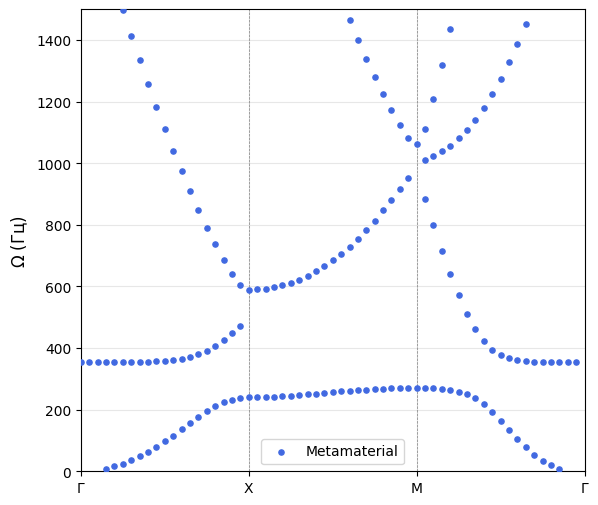

In [ ]:
class BrilloinZone:
    def __init__(self, a, b, N_seg=20):
        self.a = a
        self.b = b
        self.N_seg = N_seg

    def get_path(self):
        kx1 = np.linspace(0.0, np.pi / self.a, self.N_seg, endpoint=False)
        ky1 = np.zeros(self.N_seg)

        kx2 = np.full(self.N_seg, np.pi / self.a)
        ky2 = np.linspace(0.0, np.pi / self.b, self.N_seg, endpoint=False)
        
        kx3 = np.linspace(np.pi / self.a, 0.0, self.N_seg, endpoint=True)
        ky3 = np.linspace(np.pi / self.b, 0.0, self.N_seg, endpoint=True)

        KX = np.concatenate([kx1, kx2, kx3])
        KY = np.concatenate([ky1, ky2, ky3])
        x_path = np.arange(self.N_seg * 3) / self.N_seg
        
        return KX, KY, x_path


class MetaMaterial:
    def __init__(self, a, b, theta, m_u, ks, rho, h, D, N_T=20):
        self.a = a
        self.b = b
        self.theta = theta
        self.m_u = m_u
        self.ks = ks
        self.nu = np.sqrt(ks / m_u)
        self.rho = rho
        self.h = h
        self.D = D
        self.N_T = N_T

    def _w2k(self, w):
        return (self.rho * self.h * w**2 / self.D) ** 0.25

    def DispersionEqLhs(self, w):
        k = self._w2k(w)
        mu = self.m_u * w**2 / (self.D * (1.0 - w**2 / self.nu**2))

        return 4.0 * self.b * k**3 / mu

    def DispersionEqRhs(self, kx, ky, w):
        k = self._w2k(w)
        res = 0.0 + 0j
        
        sin_t = np.sin(self.theta)
        cot_t = 0.0 if abs(np.cos(self.theta)) < 1e-10 else 1.0 / np.tan(self.theta)

        for n in range(-self.N_T, self.N_T + 1):
            kxn = kx + 2.0 * np.pi * n / self.b
            
            lambda_n = np.sqrt((kxn / k)**2 - 1 + 0j)
            gamma_n  = np.sqrt((kxn / k)**2 + 1 + 0j)
            
            arg_gamma = gamma_n * k * self.a * sin_t
            arg_lambda = lambda_n * k * self.a * sin_t
            
            denom_left = np.cos(sin_t * (ky * self.a - 2.0 * np.pi * n * self.a * cot_t / self.b))

            num_1 = np.sinh(arg_gamma)
            den_1 = denom_left - np.cosh(arg_gamma) + 1e-9
            
            num_2 = np.sinh(arg_lambda)
            den_2 = denom_left - np.cosh(arg_lambda) + 1e-9

            res += (1.0 / (gamma_n)) * (num_1 / den_1) - (1.0 / lambda_n) * (num_2 / den_2)
            
        return np.real(res)

    def DispersionEqResidual(self, kx, ky, w):
        if w < 1e-5 or abs(w - self.nu) < 1e-1:
            return 1e5
        return self.DispersionEqLhs(w) - self.DispersionEqRhs(kx, ky, w)

    def verify(self, kx, ky, w):
        lhs = self.DispersionEqLhs(w)
        rhs = self.DispersionEqRhs(kx, ky, w)
        print(f"LHS: {lhs:.5e}, RHS: {rhs:.5e}, Разница: {lhs - rhs:.5e}")

        return lhs - rhs

    def calculate_bands(self, KX, KY, w_search_array, xtol=1e-10):
        meta_x, meta_y = [], []
        x_path = np.arange(len(KX)) / (len(KX) // 3) 
        
        for i, (kx, ky) in enumerate(zip(KX, KY)):
            if i % 10 == 0:
                print(f"  Расчет k-точки {i}/{len(KX)}")
                
            res_vals = [self.DispersionEqResidual(kx, ky, w) for w in w_search_array]
            
            for j in range(len(res_vals) - 1):
                v0, v1 = res_vals[j], res_vals[j+1]
                if np.isnan(v0) or np.isnan(v1): 
                    continue
                    
                if v0 * v1 < 0.0:
                    try:
                        w_root = brentq(lambda w_val: self.DispersionEqResidual(kx, ky, w_val),
                                        w_search_array[j], w_search_array[j+1], xtol=xtol, maxiter=400)
                    
                        if abs(self.DispersionEqResidual(kx, ky, w_root)) < 1.0:
                            meta_x.append(x_path[i])
                            meta_y.append(w_root)
                    except (ValueError, RuntimeError):
                        pass
                        
        return np.array(meta_x), np.array(meta_y)


def plot_dispersion(meta_x, meta_y, meta, bz):
    fig, ax = plt.subplots(figsize=(6.5, 6))
    
    meta_y_hz = meta_y / (2 * np.pi)
    
    ax.scatter(meta_x, meta_y_hz, s=14, color="royalblue", zorder=4, label="Metamaterial")

    x_ticks = [0, 1, 2, 3]
    path_names = ['Γ', 'X', 'M', 'Γ']
    for xc in x_ticks:
        ax.axvline(x=xc, color='gray', linestyle='--', linewidth=0.5)
        
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(path_names)
    ax.set_xlim(0, 3)
    
    ax.set_ylim(0, 1500)
    ax.set_ylabel(r'$\Omega$ (Гц)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    
    KX, KY, xpth = bz.get_path()
    def onclick(event):
        if event.xdata is None or event.ydata is None: 
            return
        kx_val = np.interp(event.xdata, xpth, KX)
        ky_val = np.interp(event.xdata, xpth, KY)
        
        w_val = event.ydata * 2 * np.pi
        
        print(f"\nКлик! x: {event.xdata:.2f} -> kx: {kx_val:.4f}, ky: {ky_val:.4f}, частота: {event.ydata:.2f} Гц")
        meta.verify(kx_val, ky_val, w_val)

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.show()


a = 0.1 
b = 0.1 
theta = np.pi / 2.0
D = 51.28 
rho = 2700
h = 0.002
m_u = 0.027
ks = 9.593 * 10**4


meta = MetaMaterial(a, b, theta, m_u, ks, rho, h, D, N_T=5)
bz = BrilloinZone(a, b, N_seg=20)

print(f"Резонансная частота осциллятора (nu): {meta.nu / (2 * np.pi):.2f} Гц")

KX, KY, xpth = bz.get_path()

f_max = 1500 
Om_search = np.linspace(0.005, f_max * 2 * np.pi, 500)

meta_x, meta_y = meta.calculate_bands(KX, KY, Om_search)
plot_dispersion(meta_x, meta_y, meta, bz)